<a href="https://colab.research.google.com/github/luijansuarez/Market-Basket-Analysis/blob/main/Case_7_MarketBasketAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Import data

In [ ]:
# Unzip the data
!unzip market_basket_data.zip

Archive:  market_basket_data.zip
  inflating: aisles.csv              
  inflating: departments.csv         
  inflating: order_products__prior.csv  
  inflating: order_products__train.csv  
  inflating: orders.csv              
  inflating: products.csv            


## Load the data

In [ ]:
aisles = pd.read_csv('aisles.csv')
departments = pd.read_csv('departments.csv')
order_products = pd.read_csv('order_products__prior.csv')
order_products__train = pd.read_csv('order_products__train.csv')
orders = pd.read_csv('orders.csv')
products = pd.read_csv('products.csv')

## Merge the data

In [ ]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [ ]:
# Merge to get product names
merged = order_products.merge(products, on='product_id', how='left')

In [ ]:
# Let's limit ourselves to just 100_000 baskets
merged = merged[merged['order_id'] < 100_000]

In [ ]:
merged['order_id'].max()

99999

# Aisle Heatmap

## Calculate the frequency of purchase of each aisle

In [ ]:
aisles_count = (
    merged.groupby("aisle_id")
    .size()
    .sort_values(ascending=False)
    .to_frame("n_items")


)

In [ ]:
aisles_count.head()

,n_items
aisle_id,
24,106456
83,99396
123,51826
120,42316
21,28482


## Create a heatmap

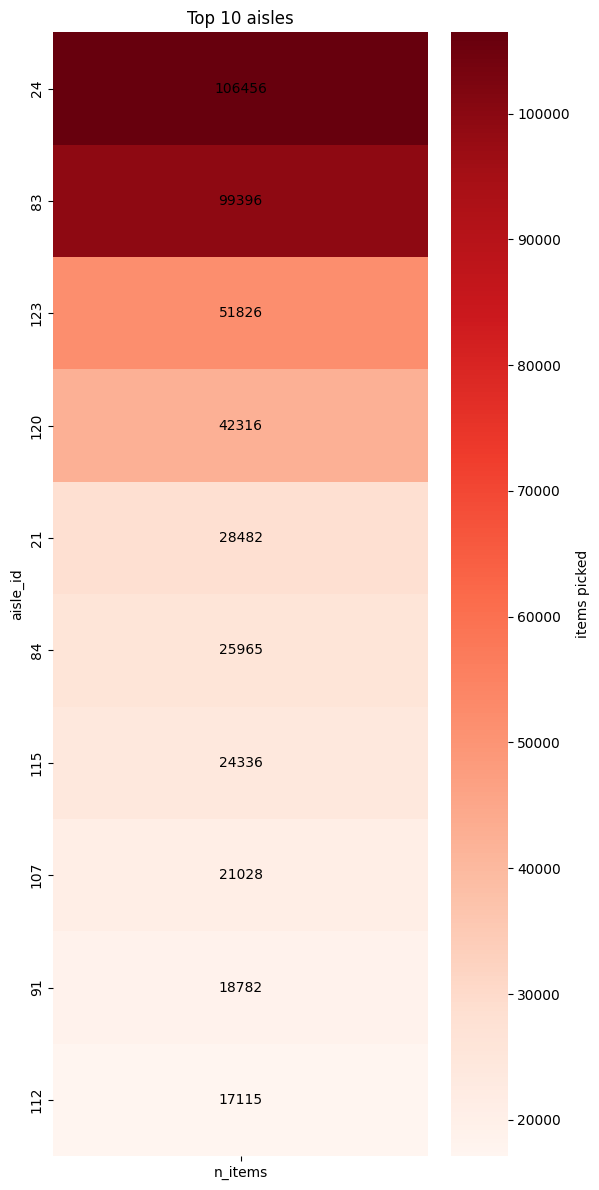

In [ ]:
plt.figure(figsize=(6, 12))
sns.heatmap(
    aisles_count.head(10),
    cmap= "Reds",
    annot=True,
    fmt="d",
    annot_kws={"size":10,"color":"black" },
    cbar_kws={"label": "items picked"}
)

plt.ylabel("aisle_id")
plt.xlabel("")
plt.title("Top 10 aisles")
plt.tight_layout()
plt.savefig("hot_aisle.png")
plt.show()

In [ ]:
aisles[aisles['aisle_id'] == 24]

,aisle_id,aisle
23,24,fresh fruits


# Basic Basket Heuristics

In [ ]:
import itertools
from tqdm import tqdm

In [ ]:
# Create baskets (list of items per order_id)
baskets = merged.groupby('order_id')['product_name'].apply(list).to_list()

In [ ]:
baskets[:2]

[['Organic Egg Whites',
  'Michigan Organic Kale',
  'Garlic Powder',
  'Coconut Butter',
  'Natural Sweetener',
  'Carrots',
  'Original Unflavored Gelatine Mix',
  'All Natural No Stir Creamy Almond Butter',
  'Classic Blend Cole Slaw'],
 ['Total 2% with Strawberry Lowfat Greek Strained Yogurt',
  'Unsweetened Almondmilk',
  'Lemons',
  'Organic Baby Spinach',
  'Unsweetened Chocolate Almond Breeze Almond Milk',
  'Organic Ginger Root',
  'Air Chilled Organic Boneless Skinless Chicken Breasts',
  'Organic Ezekiel 49 Bread Cinnamon Raisin']]

In [ ]:
len(baskets)

93947

## Brute Force

In [ ]:
# Brute force function
from collections.abc import KeysView
def brute_force(baskets, support_threshold=0.0):
  C1 = {}
  C2= {}
  T = len(baskets)
  for basket in tqdm(baskets):
    for item in basket:
      C1[item]= C1.get(item,0)+1
    for pair in itertools.combinations(basket,2):
      key = frozenset(pair)
      C2[key]= C2.get(key,0)+1
  e = math.ceil(support_threshold*T)
  C2  = {k: v for k, v in C2.items() if v >= e}
  return C1, C2, T

In [ ]:
# Run the brute force function
C1, C2, T = brute_force(baskets, support_threshold=0.01)

100%|██████████| 93947/93947 [00:18<00:00, 5012.47it/s]


In [ ]:
C2

{frozenset({'Bag of Organic Bananas', 'Organic Raspberries'}): 1209,
 frozenset({'Bag of Organic Bananas', 'Organic Hass Avocado'}): 1804,
 frozenset({'Banana', 'Organic Avocado'}): 1562,
 frozenset({'Banana', 'Organic Strawberries'}): 1709,
 frozenset({'Banana', 'Organic Baby Spinach'}): 1529,
 frozenset({'Banana', 'Cucumber Kirby'}): 942,
 frozenset({'Banana', 'Organic Hass Avocado'}): 982,
 frozenset({'Banana', 'Large Lemon'}): 1211,
 frozenset({'Organic Baby Spinach', 'Organic Hass Avocado'}): 980,
 frozenset({'Organic Baby Spinach', 'Organic Strawberries'}): 1121,
 frozenset({'Organic Hass Avocado', 'Organic Strawberries'}): 1164,
 frozenset({'Banana', 'Organic Fuji Apple'}): 965,
 frozenset({'Banana', 'Strawberries'}): 1207,
 frozenset({'Bag of Organic Bananas', 'Organic Baby Spinach'}): 1507,
 frozenset({'Bag of Organic Bananas', 'Organic Strawberries'}): 1791,
 frozenset({'Organic Raspberries', 'Organic Strawberries'}): 952}

## Calculate market basket metrics

$$
\text{support}(A) = \frac{|\{\, t \in T : A \subseteq t \,\}|}{|T|}
$$



$$
\text{support}(A \cup B) = \frac{|\{\, t \in T : A \cup B \subseteq t \,\}|}{|T|}
$$




$$
\text{confidence}(A \cup B)
= \frac{\text{support}(A \cup B)}{\text{support}(A)}
$$




$$
\text{lift}(A \rightarrow B)
= \frac{\text{support}(A \cup B)}{\text{support}(A)\,×\text{support}(B)}
$$

In [ ]:
# Create metrics function
def association_metrics(counts,assoc,N):
  metrics = {}
  for pair, count_ij in assoc.items():
    i, j = tuple(pair)
    support_ij = count_ij / N
    support_i = counts[i]/N
    support_j = counts[j] / N
    confidence_i_j = support_ij / support_i
    confidence_j_i = support_ij / support_j
    lift = support_ij / (support_i * support_j)
    xy = ' - '.join(pair)
    metrics[xy] = {
        'product_1':i,
        'product_2':j,
        'support_1': support_i,
        'support_2': support_j,
        'support_12': support_ij,
        'confidence_1_2': confidence_i_j,
        'confidence_2_1': confidence_j_i,
        'lift': lift
    }
  df= pd.DataFrame(metrics).T.reset_index(drop=True).sort_values('lift', ascending=False)
  return df


In [ ]:
# Calculate metrics from brute force results
association_metrics(C1,C2,T)

,product_1,product_2,support_1,support_2,support_12,confidence_1_2,confidence_2_1,lift
15,Organic Strawberries,Organic Raspberries,0.082472,0.042705,0.010133,0.12287,0.237288,2.877195
0,Bag of Organic Bananas,Organic Raspberries,0.119514,0.042705,0.012869,0.107677,0.301346,2.521424
11,Banana,Organic Fuji Apple,0.148435,0.027579,0.010272,0.0692,0.372443,2.509137
1,Bag of Organic Bananas,Organic Hass Avocado,0.119514,0.066048,0.019202,0.16067,0.290733,2.432626
10,Organic Strawberries,Organic Hass Avocado,0.082472,0.066048,0.01239,0.150232,0.187591,2.274597
5,Cucumber Kirby,Banana,0.030177,0.148435,0.010027,0.332275,0.067551,2.238526
8,Organic Baby Spinach,Organic Hass Avocado,0.075436,0.066048,0.010431,0.138281,0.157937,2.093653
2,Organic Avocado,Banana,0.054318,0.148435,0.016626,0.306094,0.112011,2.062148
12,Banana,Strawberries,0.148435,0.044461,0.012848,0.086554,0.288963,1.946737
14,Organic Strawberries,Bag of Organic Bananas,0.082472,0.119514,0.019064,0.231156,0.159512,1.934134


# Apriori Algorithm

## Create size 2 apriori function

In [ ]:
# Create the apriori function
def apriori_C2(baskets, support_threshold=0.01):
  T = len(baskets)
  e = math.ceil(support_threshold*T)
  C1 = {}
  for basket in tqdm(baskets):
    for item in basket:
      key = frozenset([item])
      C1[key] = C1.get(key, 0) + 1
  L1= {k:v for k,v in C1.items() if v >= e}
  C2_items= set(a.union(b) for a in L1 for b in L1 if a !=b)

  C2 = {}
  for basket in tqdm(baskets):
    for pair in itertools.combinations(basket, 2):
      key = frozenset(pair)
      if key in C2_items:
        C2[key] = C2.get(key, 0) + 1
  L2= {k:v for k,v in C2.items() if v >= e}
  L1 ={next(iter(k)):v for k,v in L1.items()}
  return L1, L2, T

In [ ]:
# Run the apriori function
L1,L2,T = apriori_C2(baskets, support_threshold=0.01)

100%|██████████| 93947/93947 [00:02<00:00, 45995.56it/s]


In [ ]:
# Calculate metrics on the apriori result
association_metrics(L1,L2,T)

,product_1,product_2,support_1,support_2,support_12,confidence_1_2,confidence_2_1,lift
15,Organic Strawberries,Organic Raspberries,0.082472,0.042705,0.010133,0.12287,0.237288,2.877195
0,Bag of Organic Bananas,Organic Raspberries,0.119514,0.042705,0.012869,0.107677,0.301346,2.521424
11,Banana,Organic Fuji Apple,0.148435,0.027579,0.010272,0.0692,0.372443,2.509137
1,Bag of Organic Bananas,Organic Hass Avocado,0.119514,0.066048,0.019202,0.16067,0.290733,2.432626
10,Organic Strawberries,Organic Hass Avocado,0.082472,0.066048,0.01239,0.150232,0.187591,2.274597
5,Cucumber Kirby,Banana,0.030177,0.148435,0.010027,0.332275,0.067551,2.238526
8,Organic Baby Spinach,Organic Hass Avocado,0.075436,0.066048,0.010431,0.138281,0.157937,2.093653
2,Organic Avocado,Banana,0.054318,0.148435,0.016626,0.306094,0.112011,2.062148
12,Banana,Strawberries,0.148435,0.044461,0.012848,0.086554,0.288963,1.946737
14,Organic Strawberries,Bag of Organic Bananas,0.082472,0.119514,0.019064,0.231156,0.159512,1.934134


## MLXTEND Apriori Library

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
# Dummify the basket data
te = TransactionEncoder()
te_ary = te.fit(baskets).transform(baskets)
df = pd.DataFrame(te_ary, columns=te.columns_)

In [ ]:
# Run the mlxtend apriori algorithm
df

,#2 Coffee Filters,#2 Cone White Coffee Filters,#4 Natural Brown Coffee Filters,& Go! Hazelnut Spread + Pretzel Sticks,+Energy Black Cherry Vegetable & Fruit Juice,0 Calorie Acai Raspberry Water Beverage,0 Calorie Fuji Apple Pear Water Beverage,0 Calorie Strawberry Dragonfruit Water Beverage,0% Fat Black Cherry Greek Yogurt y,0% Fat Blueberry Greek Yogurt,...,with Sweet Cinnamon Bunches Cereal,with Twist Ties Sandwich & Storage Bags,with Xylitol Cinnamon 18 Sticks Sugar Free Gum,with Xylitol Island Berry Lime 18 Sticks Sugar Free Gum,with Xylitol Minty Sweet Twist 18 Sticks Sugar Free Gum,with Xylitol Original Flavor 18 Sticks Sugar Free Gum,with Xylitol Unwrapped Spearmint 50 Sticks Sugar Free Gum,with Xylitol Watermelon Twist 18 Sticks Sugar Free Gum,with a Splash of Mango Coconut Water,with a Splash of Pineapple Coconut Water
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93942,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
93943,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
93944,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
93945,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# find association rules and calculate metrics with mlxtend
frequent_itemsets = apriori(
    df,
    min_support=0.01,
    use_colnames=True,
    max_len = 5)

In [ ]:
frequent_itemsets.head()

,support,itemsets
0,0.011794,(100% Raw Coconut Water)
1,0.018681,(100% Whole Wheat Bread)
2,0.011613,(2% Reduced Fat Milk)
3,0.026707,(Apple Honeycrisp Organic)
4,0.019958,(Asparagus)


In [ ]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)

In [ ]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Organic Baby Spinach),(Bag of Organic Bananas),0.075436,0.119514,0.016041,0.212643,1.779227,1.0,0.007025,1.118280,0.473692,0.089660,0.105770,0.173430
1,(Bag of Organic Bananas),(Organic Baby Spinach),0.119514,0.075436,0.016041,0.134218,1.779227,1.0,0.007025,1.067895,0.497405,0.089660,0.063578,0.173430
2,(Bag of Organic Bananas),(Organic Hass Avocado),0.119514,0.066048,0.019202,0.160670,2.432626,1.0,0.011309,1.112735,0.668860,0.115426,0.101313,0.225702
3,(Organic Hass Avocado),(Bag of Organic Bananas),0.066048,0.119514,0.019202,0.290733,2.432626,1.0,0.011309,1.241403,0.630569,0.115426,0.194460,0.225702
4,(Bag of Organic Bananas),(Organic Raspberries),0.119514,0.042705,0.012869,0.107677,2.521424,1.0,0.007765,1.072813,0.685302,0.086166,0.067871,0.204512
5,(Organic Raspberries),(Bag of Organic Bananas),0.042705,0.119514,0.012869,0.301346,2.521424,1.0,0.007765,1.260260,0.630316,0.086166,0.206513,0.204512
6,(Organic Strawberries),(Bag of Organic Bananas),0.082472,0.119514,0.019064,0.231156,1.934134,1.0,0.009207,1.145208,0.526385,0.104219,0.126796,0.195334
7,(Bag of Organic Bananas),(Organic Strawberries),0.119514,0.082472,0.019064,0.159512,1.934134,1.0,0.009207,1.091661,0.548530,0.104219,0.083965,0.195334
8,(Cucumber Kirby),(Banana),0.030177,0.148435,0.010027,0.332275,2.238526,1.0,0.005548,1.275324,0.570493,0.059477,0.215885,0.199913
9,(Banana),(Cucumber Kirby),0.148435,0.030177,0.010027,0.067551,2.238526,1.0,0.005548,1.040082,0.649718,0.059477,0.038537,0.199913


# Final Excel Automatic report

In [ ]:
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.5 MB/s eta 0:00:00


In [ ]:
import xlsxwriter

In [ ]:
output_path='market_basket_analysis_results.xlsx'

In [ ]:
hot_aisles= aisles_count.reset_index()

In [ ]:
hot_aisles=hot_aisles.merge(aisles, on='aisle_id', how='left')

In [ ]:
rules = rules.sort_values('lift', ascending=False)

In [ ]:
image_path='hot_aisle.png'
with pd.ExcelWriter(output_path,engine= 'xlsxwriter') as writer:
  workbook = writer.book
  sheet_name = 'hot aisles'
  hot_aisles.to_excel(writer, sheet_name=sheet_name, index=False)

  worksheet = writer.sheets[sheet_name]
  n_cols = hot_aisles.shape[1]
  image_col = n_cols +2
  worksheet.insert_image(1,image_col,image_path,
                        {'x_scale':0.9,
                         'y_scale':0.9})
  worksheet.set_column(0,n_cols-1,18)
  worksheet.set_column(image_col,image_col+5,25)

  rules.to_excel(
      writer,
      sheet_name='market basket analysis',
      index=False)